<h1><center><b>Financial Analytics: Homework 1</b></center></h1>

---

In [20]:
# Import Packages

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from optbinning import BinningProcess, Scorecard
from optbinning.scorecard import plot_auc_roc, plot_ks

import matplotlib.pyplot as plt

In [21]:
# Load Accepts Data

accepts = pd.read_csv("accepted_customers.csv")
accepts.head()

,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_
0,0,2,51,3,999,2,0,0,1000,1,...,1,1300,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30
1,1,2,55,60,999,2,2,0,2900,0,...,1,900,Furniture or Carpet,Owner,German,Others,Car,no credit cards,0,30
2,0,1,50,72,999,2,2,0,2300,0,...,0,1100,Radio or TV or Hifi,Lease,German,Others,Without Vehicle,no credit cards,0,30
3,0,2,56,96,999,2,2,1,4000,0,...,0,7000,Furniture or Carpet,Lease,German,Civil Service,Car,no credit cards,0,30
4,0,1,52,120,999,2,0,0,0,1,...,0,1200,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30


In [22]:
# # Normalize Column Names 

# accepts.columns = (
#     accepts.columns
#       .str.strip()
#       .str.lower()
#       .str.replace(r"[^\w]+", "_", regex=True)
# )
# accepts.head()

In [23]:
# Data Split

train, test = train_test_split(accepts, test_size=0.30, random_state=1234)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (2100, 24)
Test shape : (900, 24)


In [24]:
# Ensure GB Is Numeric 0/1

train["GB"] = pd.to_numeric(train["GB"], errors="coerce").astype(int)
test["GB"]  = pd.to_numeric(test["GB"],  errors="coerce").astype(int)

if "_freq_" not in train.columns:
    train["_freq_"] = 1.0
if "_freq_" not in test.columns:
    test["_freq_"] = 1.0

train[["GB", "_freq_"]].head()

,GB,_freq_
1970,1,1
2324,1,1
1885,1,1
2371,1,1
1023,0,30


In [25]:
# Binning Process & Variable Selection by IV

colnames = list(train.columns)

# Exclude obvious non-predictors if present
for drop_col in ["GB", "_freq_"]:
    if drop_col in colnames:
        colnames.remove(drop_col)

X_train = train[colnames]
y_train = train["GB"]

selection_criteria = {"iv": {"min": 0.1, "max": 1}}

categorical_vars = ['PRODUCT', 'NAT', 'PROF', 'CAR', 'CARDS', 'BUREAU', 'REGN', 'TEL', 'DIV', 'EC_CARD', 'FINLOAN', 'LOCATION', 'RESID']
categorical_vars = [c for c in categorical_vars if c in X_train.columns]

bin_proc = BinningProcess(
    variable_names=colnames,
    selection_criteria=selection_criteria,
    categorical_variables=categorical_vars
)

summary = bin_proc.fit(X_train, y_train).summary()
summary.sort_values("iv", ascending=False).head(15)

c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
2,AGE,numerical,OPTIMAL,True,8,0.389083,0.047006,0.341598,0.111394
8,INCOME,numerical,OPTIMAL,True,8,0.268925,0.032929,0.287504,0.133748
21,CARDS,categorical,OPTIMAL,True,2,0.189327,0.023299,0.193474,0.382846
4,TMJOB1,numerical,OPTIMAL,True,8,0.17702,0.021569,0.220274,0.053874
1,PERS_H,numerical,OPTIMAL,True,4,0.176798,0.021889,0.214955,0.253062
9,EC_CARD,categorical,OPTIMAL,True,2,0.157998,0.019456,0.171809,0.312224
5,TEL,categorical,OPTIMAL,False,2,0.057385,0.007107,0.09124,0.093116
0,CHILDREN,numerical,OPTIMAL,False,4,0.047069,0.00587,0.111133,0.008188
19,PROF,categorical,OPTIMAL,False,4,0.045712,0.005667,0.092525,0.027403
3,TMADD,numerical,OPTIMAL,False,4,0.040261,0.005009,0.098356,0.094559


In [26]:
# Fit the Scorecard (Logistic Regression + PDO Scaling)

estimator = LogisticRegression(solver="lbfgs", max_iter=2000)

scorecard = Scorecard(
    binning_process=bin_proc,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,
        "scorecard_points": 500,
        "odds": 20
    }
)

scorecard.fit(X_train, y_train, sample_weight=train["_freq_"])



c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_

c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_

Scorecard(binning_process=BinningProcess(categorical_variables=['PRODUCT',
                                                                'NAT', 'PROF',
                                                                'CAR', 'CARDS',
                                                                'BUREAU',
                                                                'REGN', 'TEL',
                                                                'DIV',
                                                                'EC_CARD',
                                                                'FINLOAN',
                                                                'LOCATION',
                                                                'RESID'],
                                         selection_criteria={'iv': {'max': 1,
                                                                    'min': 0.1}},
                                         variable_names=['CHILDREN', 'PERS_H',
                                                         'AGE', 'TMADD',
                                                         'TMJOB1', 'TEL',
                                                         'NMBLOAN', 'FINLOAN',
                                                         'INCOME', 'EC_CARD',
                                                         'BUREAU', 'LOCATION',
                                                         'LOANS', 'REGN', 'DIV',
                                                         'CASH', 'PRODUCT',
                                                         'RESID', 'NAT', 'PROF',
                                                         'CAR', 'CARDS']),
          estimator=LogisticRegression(max_iter=2000),
          scaling_method='pdo_odds',
          scaling_method_params={'odds': 20, 'pdo': 50,
                                 'scorecard_points': 500})

In [27]:
# Scorecard Summary

scorecard.table(style="summary")

,Variable,Bin,Points
0,PERS_H,"(-inf, 1.50)",71.498191
1,PERS_H,"[1.50, 2.50)",100.759814
2,PERS_H,"[2.50, 4.50)",97.921198
3,PERS_H,"[4.50, inf)",89.855555
4,PERS_H,Special,88.281981
5,PERS_H,Missing,88.281981
0,AGE,"(-inf, 20.50)",28.227887
1,AGE,"[20.50, 22.50)",31.018293
2,AGE,"[22.50, 27.50)",58.124867
3,AGE,"[27.50, 30.50)",84.407152


c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


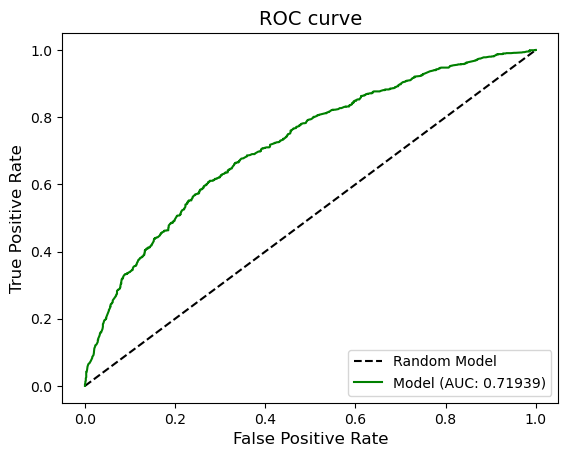

c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


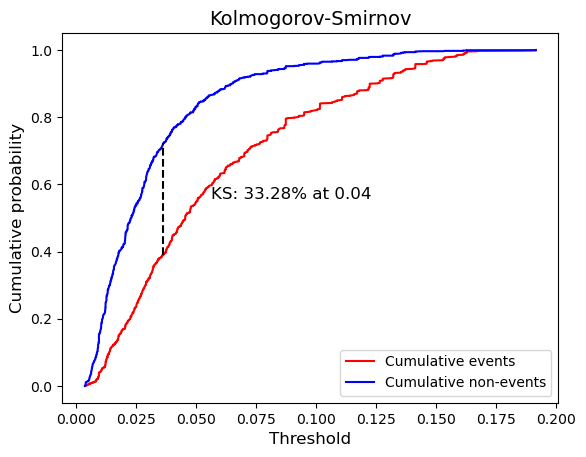

In [28]:
# Model Evaluation (Training Data)

y_pred_train = scorecard.predict_proba(X_train)[:, 1]

plot_auc_roc(y_train, y_pred_train)
plt.show()

plot_ks(y_train, y_pred_train)
plt.show()

c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


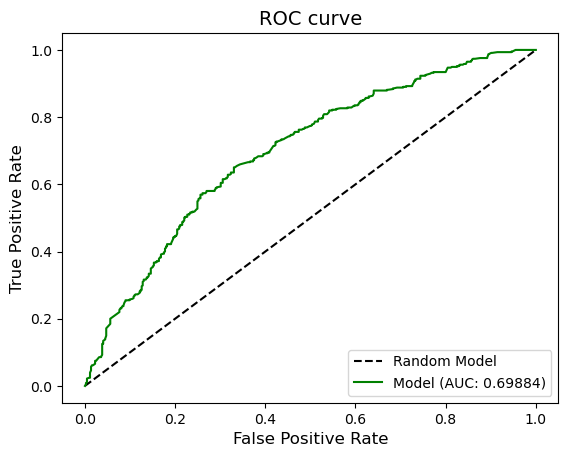

c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


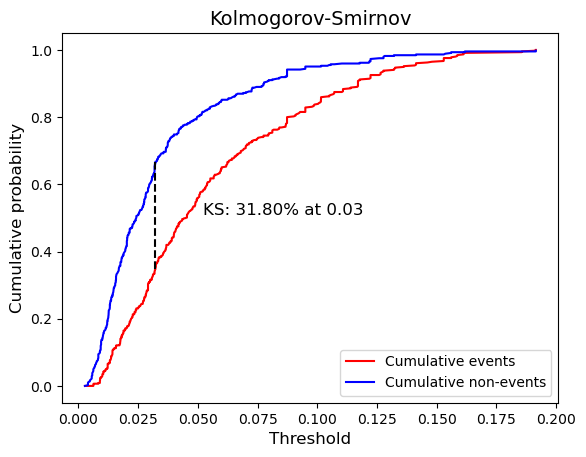

In [29]:
# Model Evaluation (Test Data)

X_test = test[colnames]
y_test = test["GB"]

y_pred_test = scorecard.predict_proba(X_test)[:, 1]

plot_auc_roc(y_test, y_pred_test)
plt.show()

plot_ks(y_test, y_pred_test)
plt.show()

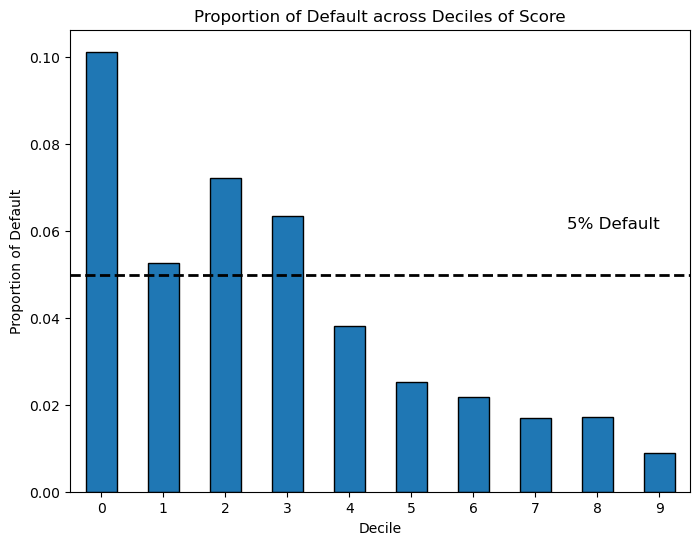

In [30]:
# Generate Scores and Decile PD Plot

# Recreate canonical split (robust to running this chunk standalone)
accepts = pd.read_csv("accepted_customers.csv")
train_tmp, test_tmp = train_test_split(accepts, test_size=0.30, random_state=1234)

test_final = test_tmp.copy()

# Ensure weight exists
if '_freq_' not in test_final.columns:
    test_final['_freq_'] = 1.0

# Score using the fitted optbinning scorecard and the predictor list `colnames`
test_final['score'] = scorecard.score(test_final[colnames])

test_final[['score', 'GB']].head()

good_weight = 30

test_final["decile"] = pd.qcut(test_final["score"], 10, labels=False)

# Counts by decile
bad_ct = test_final.loc[test_final['GB'] == 1].groupby("decile").size()
good_ct = test_final.loc[test_final['GB'] == 0].groupby("decile").size()

# Align indices to ensure 0.9 exist
all_dec = pd.Index(range(10), name="decile")
bad_ct = bad_ct.reindex(all_dec, fill_value=0)
good_ct = good_ct.reindex(all_dec, fill_value=0)

PD = bad_ct / (good_ct * good_weight + bad_ct)

plt.figure(figsize=(8, 6))
PD.plot(kind="bar", edgecolor="black")
plt.axhline(y=0.05, color="black", linestyle="--", linewidth=2)
plt.text(x=9, y=0.06, s="5% Default", color="black", ha="right", va="bottom", fontsize=12)

plt.title("Proportion of Default across Deciles of Score")
plt.xlabel("Decile")
plt.ylabel("Proportion of Default")
plt.xticks(rotation=0)
plt.show()

In [33]:
# Rejects Inference

rejects_path = "rejected_customers.csv"

if os.path.exists(rejects_path):
    rejects = pd.read_csv(rejects_path)

    # Ensure the rejects file has the predictor columns needed
    missing = [c for c in colnames if c not in rejects.columns]
    if missing:
        raise ValueError(f"rejects.csv is missing required columns: {missing}")

    X_r = rejects[colnames].copy()
    rejects["y_pred"] = scorecard.predict_proba(X_r)[:, 1]

    cutoff = 0.06
    rejects["GB"] = (rejects["y_pred"] > cutoff).astype(int)

    rejects["_freq_"] = rejects["GB"].apply(lambda x: 4.75 if x == 0 else 1.0)
    rejects = rejects.drop(columns=["y_pred"])

    comb_hard = pd.concat([accepts, rejects.head(1876)], ignore_index=True)

    print("rejects loaded and combined. comb_hard shape:", comb_hard.shape)
    comb_hard.head()
else:
    print("No rejects.csv found — skipping reject inference section.")

rejects loaded and combined. comb_hard shape: (4500, 24)


In [38]:
#Default Rate vs Acceptance Rate Across Score

def plot_default_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "bad",
    weight_col: str | None = None,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Default Rate by Acceptance Across Score",
):
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin using in-frame weights (avoids index alignment bugs)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "bad_wt": float((g[bad_col] * g[weight_col]).sum())
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_bad_wt"] = grp["bad_wt"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt
    grp["default_rate_pct"] = 100.0 * grp["cum_bad_wt"] / grp["cum_wt"]

    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["default_rate_pct"] = grp["default_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(grp["_score_mid"], grp["default_rate_pct"], label="Default Rate (%)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Default Rate (%)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()
    return grp

C:\Users\irvin\AppData\Local\Temp\ipykernel_30356\1803074534.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


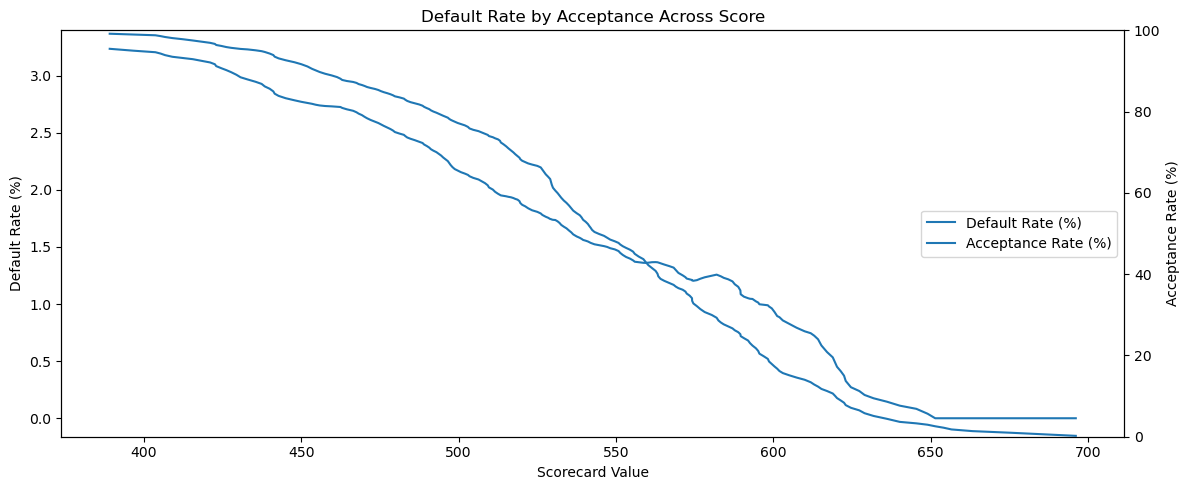

,_score_mid,wt,bad_wt,cum_wt,cum_bad_wt,accept_rate_pct,default_rate_pct
0,696.1165,30.0,0.0,30.0,0.0,0.217313,0.0
1,675.4500,210.0,0.0,240.0,0.0,0.977907,0.0
2,663.3260,60.0,0.0,300.0,0.0,1.376313,0.0
3,656.6110,120.0,0.0,420.0,0.0,1.792829,0.0
4,654.1250,120.0,0.0,540.0,0.0,2.216588,0.0


In [39]:
# Plot 

curve = plot_default_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col="GB",
    weight_col="_freq_" if "_freq_" in test_final.columns else None,
    n_bins=250,
    smooth_window=9,
    title="Default Rate by Acceptance Across Score"
)

curve.head()

In [41]:
# Profit vs Acceptance Rate by Score

def plot_profit_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "bad",
    weight_col: str | None = None,
    profit_if_good: float = 2000.0,
    loss_if_bad: float = 20000.0,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Profit by Acceptance Across Score",
):
    """
    Plot cumulative expected Profit ($) vs Acceptance Rate (%) across score cutoffs.

    For each cutoff score c:
      accepted = rows with score >= c
      acceptance rate = accepted / total
      profit($) = sum_over_accepted( weight * (profit_if_good*(1-bad) - loss_if_bad*bad) )
    """
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Per-row profit contribution
    d["_profit"] = d[weight_col] * (profit_if_good * (1 - d[bad_col]) - loss_if_bad * d[bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin (index-safe)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "profit": float(g["_profit"].sum()),
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_profit"] = grp["profit"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt

    # Optional smoothing (rolling mean)
    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["cum_profit"] = grp["cum_profit"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    # Plot with two y-axes
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(grp["_score_mid"], grp["cum_profit"], label="Profit ($)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Profit ($)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    # Combined legend on the right
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()

    return grp

C:\Users\irvin\AppData\Local\Temp\ipykernel_30356\339388416.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


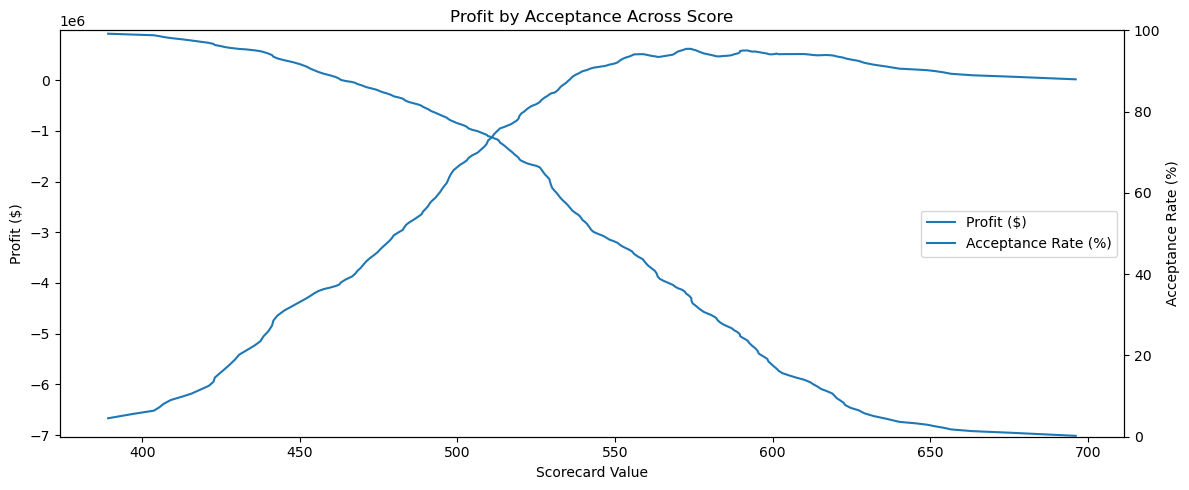

,_score_mid,wt,profit,cum_wt,cum_profit,accept_rate_pct
0,696.1165,30.0,15000.0,30.0,15000.0,0.217313
1,675.4500,210.0,105000.0,240.0,67500.0,0.977907
2,663.3260,60.0,30000.0,300.0,95000.0,1.376313
3,656.6110,120.0,60000.0,420.0,123750.0,1.792829
4,654.1250,120.0,60000.0,540.0,153000.0,2.216588


In [ ]:
# Plot

profit_if_good = 500.0   # profit on a good loan
loss_if_bad    = 30000.0  # loss on a bad loan (positive number)

profit_curve = plot_profit_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col="GB",
    weight_col="_freq_" if "_freq_" in test_final.columns else None,
    profit_if_good=profit_if_good,
    loss_if_bad=loss_if_bad,
    n_bins=250,
    smooth_window=9,
    title="Profit by Acceptance Across Score"
)

profit_curve.head()

